Import Libraries


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


Load & Preprocess Dataset

In [2]:
import kagglehub

# Download dataset from Kaggle
path = kagglehub.dataset_download("ealaxi/paysim1")

# Define file path
file_path = path + "/PS_20174392719_1491204439457_log.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# Encode categorical column
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

# Select features
features = ["step", "type", "amount",
            "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest"]

X = df[features].values
y = df["isFraud"].values

INPUT_DIM = X.shape[1]


100%|██████████| 178M/178M [00:06<00:00, 26.8MB/s]

Extracting files...


Dataset shape: (6362620, 11)


Create Non-IID Split (Dirichlet Distribution)

In [3]:
NUM_CLIENTS = 12
alpha = 0.5

def dirichlet_split(X, y, num_clients, alpha):
    data_per_client = [[] for _ in range(num_clients)]
    labels = np.unique(y)

    for label in labels:
        idx = np.where(y == label)[0]
        np.random.shuffle(idx)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        split_idx = np.split(idx, proportions)

        for i in range(num_clients):
            data_per_client[i].extend(split_idx[i])

    clients_data = {}
    for i in range(num_clients):
        client_idx = data_per_client[i]
        clients_data[i] = {
            "X": X[client_idx],
            "y": y[client_idx]
        }

    return clients_data

clients_data = dirichlet_split(X, y, NUM_CLIENTS, alpha)


In [17]:
# make Train/Test split for each bank
clients_final_data = {}

for i in range(NUM_CLIENTS):
    X_c = clients_data[i]["X"]
    y_c = clients_data[i]["y"]

    # Split each bank's data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

    clients_final_data[i] = {
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test
    }

print("✅ Each bank now has separate Train and Test sets.")

✅ Each bank now has separate Train and Test sets.


In [18]:
def analyze_clients(clients_data):
    print("\nClient Data Distribution:\n")

    for client_id in clients_data:
        X_client = clients_data[client_id]["X"]
        y_client = clients_data[client_id]["y"]

        total_samples = len(y_client)
        fraud_samples = np.sum(y_client == 1)
        nonfraud_samples = np.sum(y_client == 0)
        fraud_percentage = (fraud_samples / total_samples) * 100

        print(f"Client {client_id+1}")
        print(f"  Total Samples     : {total_samples}")
        print(f"  Fraud Samples     : {fraud_samples}")
        print(f"  Non-Fraud Samples : {nonfraud_samples}")
        print(f"  Fraud %           : {fraud_percentage:.4f}%")
        print("-" * 40)

# Run analysis
analyze_clients(clients_data)


Client Data Distribution:

Client 1
  Total Samples     : 10183
  Fraud Samples     : 1130
  Non-Fraud Samples : 9053
  Fraud %           : 11.0969%
----------------------------------------
Client 2
  Total Samples     : 1335843
  Fraud Samples     : 1433
  Non-Fraud Samples : 1334410
  Fraud %           : 0.1073%
----------------------------------------
Client 3
  Total Samples     : 912411
  Fraud Samples     : 1446
  Non-Fraud Samples : 910965
  Fraud %           : 0.1585%
----------------------------------------
Client 4
  Total Samples     : 88731
  Fraud Samples     : 750
  Non-Fraud Samples : 87981
  Fraud %           : 0.8453%
----------------------------------------
Client 5
  Total Samples     : 1810058
  Fraud Samples     : 431
  Non-Fraud Samples : 1809627
  Fraud %           : 0.0238%
----------------------------------------
Client 6
  Total Samples     : 107022
  Fraud Samples     : 1291
  Non-Fraud Samples : 105731
  Fraud %           : 1.2063%
-------------------------

Local Training (without FL)

In [5]:
import tensorflow as tf

def create_model(input_dim):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [6]:
NUM_CLIENTS = 12
LOCAL_EPOCHS = 5
BATCH_SIZE = 2048

client_models_noFL = []

print("\nTraining models WITHOUT Federated Learning\n")

for client_id in range(NUM_CLIENTS):

    print(f"Training Client {client_id+1} model...")

    X_client = clients_data[client_id]["X"]
    y_client = clients_data[client_id]["y"]

    model = create_model(X_client.shape[1])

    model.fit(
        X_client,
        y_client,
        epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    client_models_noFL.append(model)


Training models WITHOUT Federated Learning

Training Client 1 model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Client 2 model...
Training Client 3 model...
Training Client 4 model...
Training Client 5 model...
Training Client 6 model...
Training Client 7 model...
Training Client 8 model...
Training Client 9 model...
Training Client 10 model...
Training Client 11 model...
Training Client 12 model...


In [7]:
print("\nEvaluating Fraud Detection Accuracy (No FL)\n")

total_acc = 0

for client_id in range(NUM_CLIENTS):

    X_test = clients_data[client_id]["X"]
    y_test = clients_data[client_id]["y"]

    loss, acc = client_models_noFL[client_id].evaluate(
        X_test,
        y_test,
        verbose=0
    )

    print(f"Client {client_id+1} Fraud Detection Accuracy: {acc:.4f}")

    total_acc += acc

print("\nAverage Accuracy (No Federated Learning):", total_acc/NUM_CLIENTS)


Evaluating Fraud Detection Accuracy (No FL)

Client 1 Fraud Detection Accuracy: 0.8770
Client 2 Fraud Detection Accuracy: 0.9995
Client 3 Fraud Detection Accuracy: 0.9992
Client 4 Fraud Detection Accuracy: 0.9950
Client 5 Fraud Detection Accuracy: 0.9999
Client 6 Fraud Detection Accuracy: 0.9949
Client 7 Fraud Detection Accuracy: 0.6337
Client 8 Fraud Detection Accuracy: 0.9999
Client 9 Fraud Detection Accuracy: 0.9948
Client 10 Fraud Detection Accuracy: 1.0000
Client 11 Fraud Detection Accuracy: 0.8033
Client 12 Fraud Detection Accuracy: 0.9983

Average Accuracy (No Federated Learning): 0.9412787805000941


Create Model (Used for FedAvg & FedBN)

In [8]:
def create_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


FedAvg Aggregation

In [9]:
def fedavg_aggregate(client_weights):
    new_weights = []
    for weights in zip(*client_weights):
        new_weights.append(np.mean(weights, axis=0))
    return new_weights


In [11]:
#Accuracy Evaluation
def evaluate_accuracy(model, clients_data):
    total_acc = 0
    for client_id in clients_data:
        loss, acc = model.evaluate(
            clients_data[client_id]["X"],
            clients_data[client_id]["y"],
            verbose=0
        )
        print(f"Client {client_id+1} Accuracy: {acc:.4f}")
        total_acc += acc

    print(f"Average Accuracy: {total_acc/len(clients_data):.4f}\n")


Federated Training Loop (FedAvg Example)

In [12]:
NUM_ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 1024

global_model = create_model()

for round_num in range(NUM_ROUNDS):
    print(f"--- Global Round {round_num+1} ---")

    client_weights = []

    for client_id in range(NUM_CLIENTS):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        local_model.fit(
            clients_data[client_id]["X"],
            clients_data[client_id]["y"],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        client_weights.append(local_model.get_weights())

    # Server Aggregation
    new_weights = fedavg_aggregate(client_weights)
    global_model.set_weights(new_weights)

    # Evaluate
    evaluate_accuracy(global_model, clients_data)


--- Global Round 1 ---
Client 1 Accuracy: 0.9332
Client 2 Accuracy: 0.9874
Client 3 Accuracy: 0.9873
Client 4 Accuracy: 0.9839
Client 5 Accuracy: 0.9878
Client 6 Accuracy: 0.9818
Client 7 Accuracy: 0.8620
Client 8 Accuracy: 0.9881
Client 9 Accuracy: 0.9848
Client 10 Accuracy: 0.9880
Client 11 Accuracy: 0.9068
Client 12 Accuracy: 0.9880
Average Accuracy: 0.9649

--- Global Round 2 ---
Client 1 Accuracy: 0.9337
Client 2 Accuracy: 0.9993
Client 3 Accuracy: 0.9989
Client 4 Accuracy: 0.9947
Client 5 Accuracy: 0.9998
Client 6 Accuracy: 0.9927
Client 7 Accuracy: 0.8442
Client 8 Accuracy: 0.9998
Client 9 Accuracy: 0.9962
Client 10 Accuracy: 0.9999
Client 11 Accuracy: 0.9018
Client 12 Accuracy: 0.9992
Average Accuracy: 0.9717

--- Global Round 3 ---
Client 1 Accuracy: 0.9275
Client 2 Accuracy: 0.9993
Client 3 Accuracy: 0.9989
Client 4 Accuracy: 0.9944
Client 5 Accuracy: 0.9998
Client 6 Accuracy: 0.9922
Client 7 Accuracy: 0.8275
Client 8 Accuracy: 0.9999
Client 9 Accuracy: 0.9958
Client 10 Accur

FedBN Aggregation

In [13]:
def fedbn_aggregate(client_weights, global_model):
    new_weights = global_model.get_weights()

    # Identify BatchNorm layers
    bn_layers = []
    for i, layer in enumerate(global_model.layers):
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            bn_layers.append(i)

    # Go through each layer's weights
    weight_index = 0
    for layer_idx, layer in enumerate(global_model.layers):
        layer_weights = layer.get_weights()
        num_weights = len(layer_weights)

        if num_weights == 0:
            continue

        # If not BatchNorm → average normally
        if layer_idx not in bn_layers:
            averaged = []
            for weights in zip(*[client_weights[c][weight_index:weight_index+num_weights]
                                 for c in range(len(client_weights))]):
                averaged.append(np.mean(weights, axis=0))

            new_weights[weight_index:weight_index+num_weights] = averaged

        # Move weight index
        weight_index += num_weights

    return new_weights


FedBN Training Loop

In [14]:
NUM_ROUNDS = 3
LOCAL_EPOCHS = 4
BATCH_SIZE = 2048

global_fedbn_model = create_model()

print("\nStarting Federated Training using FedBN\n")

for round_num in range(NUM_ROUNDS):
    print(f"--- Global Round {round_num+1} ---")

    client_weights = []

    for client_id in range(NUM_CLIENTS):
        local_model = create_model()
        local_model.set_weights(global_fedbn_model.get_weights())

        local_model.fit(
            clients_data[client_id]["X"],
            clients_data[client_id]["y"],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        client_weights.append(local_model.get_weights())

    # FedBN aggregation
    new_weights = fedbn_aggregate(client_weights, global_fedbn_model)
    global_fedbn_model.set_weights(new_weights)

    evaluate_accuracy(global_fedbn_model, clients_data)



Starting Federated Training using FedBN

--- Global Round 1 ---
Client 1 Accuracy: 0.1759
Client 2 Accuracy: 0.0752
Client 3 Accuracy: 0.0755
Client 4 Accuracy: 0.0807
Client 5 Accuracy: 0.0742
Client 6 Accuracy: 0.0856
Client 7 Accuracy: 0.3140
Client 8 Accuracy: 0.0743
Client 9 Accuracy: 0.0785
Client 10 Accuracy: 0.0738
Client 11 Accuracy: 0.2282
Client 12 Accuracy: 0.0772
Average Accuracy: 0.1177

--- Global Round 2 ---
Client 1 Accuracy: 0.3538
Client 2 Accuracy: 0.2774
Client 3 Accuracy: 0.2771
Client 4 Accuracy: 0.2829
Client 5 Accuracy: 0.2761
Client 6 Accuracy: 0.2835
Client 7 Accuracy: 0.4537
Client 8 Accuracy: 0.2769
Client 9 Accuracy: 0.2793
Client 10 Accuracy: 0.2762
Client 11 Accuracy: 0.3984
Client 12 Accuracy: 0.2782
Average Accuracy: 0.3095

--- Global Round 3 ---
Client 1 Accuracy: 0.5058
Client 2 Accuracy: 0.4545
Client 3 Accuracy: 0.4542
Client 4 Accuracy: 0.4615
Client 5 Accuracy: 0.4537
Client 6 Accuracy: 0.4588
Client 7 Accuracy: 0.5906
Client 8 Accuracy: 0.4541

In [15]:
# Create a list of 12 models that stay in memory
client_models = [create_model() for _ in range(NUM_CLIENTS)]

# Initialize them all with the same global weights at the start
initial_weights = global_fedbn_model.get_weights()
for model in client_models:
    model.set_weights(initial_weights)

In [16]:
import tensorflow as tf

# Function to sync non-BN weights from global model to local model
def sync_non_bn_weights(global_model, local_model):
    global_weights = global_model.get_weights()
    local_weights = local_model.get_weights() # This will be modified

    current_weight_index = 0
    # Iterate through the layers of the model
    # Note: `global_model` and `local_model` have the same architecture
    for layer_idx, layer in enumerate(global_model.layers):
        # Get the number of weight tensors for the current layer
        num_weights_in_layer = len(layer.get_weights())

        if num_weights_in_layer > 0 and not isinstance(layer, tf.keras.layers.BatchNormalization):
            # If it's not a BatchNorm layer and has weights, copy weights from global to local
            for i in range(num_weights_in_layer):
                local_weights[current_weight_index + i] = global_weights[current_weight_index + i]

        # Advance the weight index by the number of weights in this layer
        current_weight_index += num_weights_in_layer

    # Set the updated weights to the local model
    local_model.set_weights(local_weights)

# Function to evaluate accuracy for FedBN (using local models)
def evaluate_accuracy_fedbn(client_models, clients_data):
    total_acc = 0
    for client_id in range(len(client_models)): # Iterate through client models
        # Use the specific client's model to evaluate on its data
        loss, acc = client_models[client_id].evaluate(
            clients_data[client_id]["X"],
            clients_data[client_id]["y"],
            verbose=0
        )
        print(f"Client {client_id+1} Accuracy: {acc:.4f}")
        total_acc += acc

    print(f"Average Accuracy: {total_acc/len(client_models):.4f}\n")

for round_num in range(NUM_ROUNDS):
    print(f"--- Global Round {round_num+1} ---")
    all_client_weights = []

    for client_id in range(NUM_CLIENTS):
        # 1. Get the persistent local model for this bank
        local_model = client_models[client_id]

        # 2. Update ONLY the non-BN weights from the global model
        # You need a helper to sync only the FC/Linear layers
        sync_non_bn_weights(global_fedbn_model, local_model)

        # 3. Train locally (BN layers update based on local data)
        local_model.fit(
            clients_data[client_id]["X"],
            clients_data[client_id]["y"],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        all_client_weights.append(local_model.get_weights())

    # 4. Aggregation (Server averages only the non-BN layers)
    new_global_weights = fedbn_aggregate(all_client_weights, global_fedbn_model)
    global_fedbn_model.set_weights(new_global_weights)

    # 5. Evaluation: For FedBN, you evaluate using the local models
    evaluate_accuracy_fedbn(client_models, clients_data)


--- Global Round 1 ---
Client 1 Accuracy: 0.9226
Client 2 Accuracy: 0.9991
Client 3 Accuracy: 0.9993
Client 4 Accuracy: 0.9963
Client 5 Accuracy: 0.9999
Client 6 Accuracy: 0.9950
Client 7 Accuracy: 0.8194
Client 8 Accuracy: 0.9999
Client 9 Accuracy: 0.9970
Client 10 Accuracy: 1.0000
Client 11 Accuracy: 0.8904
Client 12 Accuracy: 0.9989
Average Accuracy: 0.9681

--- Global Round 2 ---
Client 1 Accuracy: 0.9642
Client 2 Accuracy: 0.9995
Client 3 Accuracy: 0.9992
Client 4 Accuracy: 0.9967
Client 5 Accuracy: 0.9999
Client 6 Accuracy: 0.9954
Client 7 Accuracy: 0.8649
Client 8 Accuracy: 0.9999
Client 9 Accuracy: 0.9971
Client 10 Accuracy: 1.0000
Client 11 Accuracy: 0.9455
Client 12 Accuracy: 0.9994
Average Accuracy: 0.9801

--- Global Round 3 ---
Client 1 Accuracy: 0.9632
Client 2 Accuracy: 0.9995
Client 3 Accuracy: 0.9993
Client 4 Accuracy: 0.9969
Client 5 Accuracy: 0.9999
Client 6 Accuracy: 0.9954
Client 7 Accuracy: 0.8856
Client 8 Accuracy: 0.9999
Client 9 Accuracy: 0.9977
Client 10 Accur

In [19]:
#list Results store
local_final_acc = []
fedavg_final_acc = []
fedbn_final_acc = []

# collect Local Training Accuracy
for client_id in range(NUM_CLIENTS):
    loss, acc = client_models_noFL[client_id].evaluate(
        clients_final_data[client_id]["X_test"],
        clients_final_data[client_id]["y_test"], verbose=0)
    local_final_acc.append(acc)

# collect FedAvg Accuracy   (Global model eken rounds iwara unama)
for client_id in range(NUM_CLIENTS):
    loss, acc = global_model.evaluate(
        clients_final_data[client_id]["X_test"],
        clients_final_data[client_id]["y_test"], verbose=0)
    fedavg_final_acc.append(acc)

# collect FedBN Accuracy (Local models walin rounds iwara unama)
for client_id in range(NUM_CLIENTS):
    loss, acc = client_models[client_id].evaluate(
        clients_final_data[client_id]["X_test"],
        clients_final_data[client_id]["y_test"], verbose=0)
    fedbn_final_acc.append(acc)

#Visualization Part

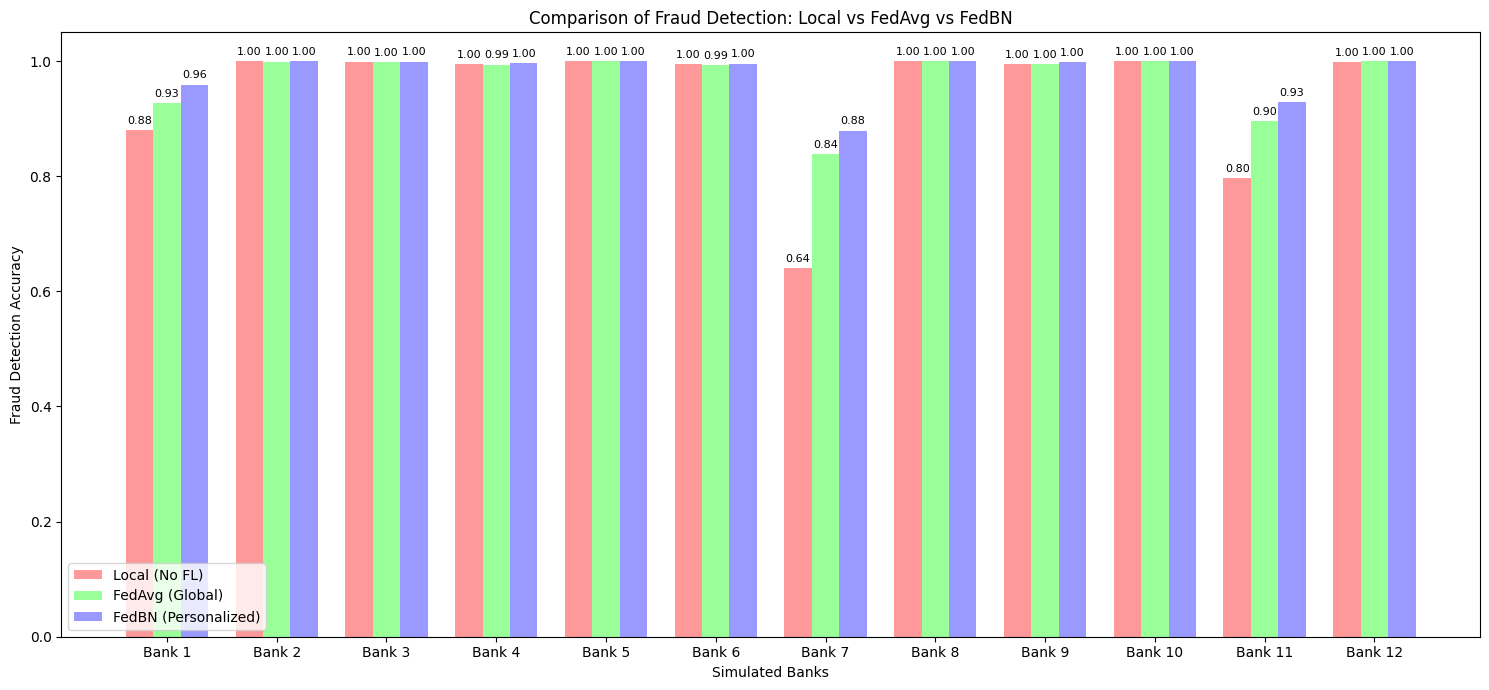

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
banks = [f"Bank {i+1}" for i in range(NUM_CLIENTS)]
x = np.arange(len(banks))
width = 0.25

# Create Plot
fig, ax = plt.subplots(figsize=(15, 7))

rects1 = ax.bar(x - width, local_final_acc, width, label='Local (No FL)', color='#FF9999')
rects2 = ax.bar(x, fedavg_final_acc, width, label='FedAvg (Global)', color='#99FF99')
rects3 = ax.bar(x + width, fedbn_final_acc, width, label='FedBN (Personalized)', color='#9999FF')

# Labels & Titles
ax.set_xlabel('Simulated Banks')
ax.set_ylabel('Fraud Detection Accuracy')
ax.set_title('Comparison of Fraud Detection: Local vs FedAvg vs FedBN')
ax.set_xticks(x)
ax.set_xticklabels(banks)
ax.legend()

# Accuracy values bars in top
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()